# Comprehensive Dataset Analysis
This notebook provides a step-by-step analysis of the train, validation, and test datasets for temporal graph neural networks. We will explore adjacency matrix properties, node features, homophily, up ratios, and more.

In [1]:
# Import required libraries
from dataset_analyzer import MarketAnalyzer
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Datasets
We load the train, validation, and test datasets using the MarketAnalyzer class.

In [2]:
MARKET = 'NASDAQ'
NORMALIZATION = 'log1p'
WINDOW_SIZE = 19

train_path = Path(f"/home/mbisoffi/tests/TemporalGNNReview/code/data/datasets/graph/{MARKET}_Train_2016-05-01_2017-06-30_{WINDOW_SIZE}_{NORMALIZATION}")
val_path = Path(f"/home/mbisoffi/tests/TemporalGNNReview/code/data/datasets/graph/{MARKET}_Validation_2017-07-01_2017-12-31_{WINDOW_SIZE}_{NORMALIZATION}")
test_path = Path(f"/home/mbisoffi/tests/TemporalGNNReview/code/data/datasets/graph/{MARKET}_Test_2018-01-01_2019-12-31_{WINDOW_SIZE}_{NORMALIZATION}")
    
train_analyzer = MarketAnalyzer(train_path, adj_minmax=False,  threshold=.25)
val_analyzer = MarketAnalyzer(val_path, train_path=train_path, adj_minmax=False, threshold=.25)
test_analyzer = MarketAnalyzer(test_path, train_path=train_path, adj_minmax=False,  threshold=.25)
skip_adj_distribution_analysis = True

|             Dataset Information             |
| Market Name:         NASDAQ                  |
| Time Period:         Train                   |
| Start Date:          2016-05-01              |
| End Date:            2017-06-30              |
| Window Size:         19                      |
| Normalizer:          log1p                   |
| Number of Features:  5                       |
| Number of Nodes:     721                     |
| Number of Snapshots: 208                     |
Folder analysis_results already exists at /home/mbisoffi/tests/TemporalGNNReview/code/data/datasets/graph/NASDAQ_Train_2016-05-01_2017-06-30_19_log1p
|             Dataset Information             |
| Market Name:         NASDAQ                  |
| Time Period:         Validation              |
| Start Date:          2017-07-01              |
| End Date:            2017-12-31              |
| Window Size:         19                      |
| Normalizer:          log1p                   |
| Number of Feature

## Extract Snapshots Info
Get snapshot-level information for each dataset.

In [3]:
train_snapshots_info = train_analyzer.get_snapshots_info()
val_snapshots_info = val_analyzer.get_snapshots_info()
test_snapshots_info = test_analyzer.get_snapshots_info()

train_df = pd.DataFrame(train_snapshots_info)
train_df['dataset'] = 'train'
val_df = pd.DataFrame(val_snapshots_info)
val_df['dataset'] = 'validation'
test_df = pd.DataFrame(test_snapshots_info)
test_df['dataset'] = 'test'
all_snapshots_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

## Adjacency Matrix Analysis
Analyze properties of the adjacency matrices: density, connectivity, and degree distribution.

In [4]:
adj_matrices = train_analyzer.get_snapshots_adjacency_matrix()

Adjacency matrix shape: (721, 721)


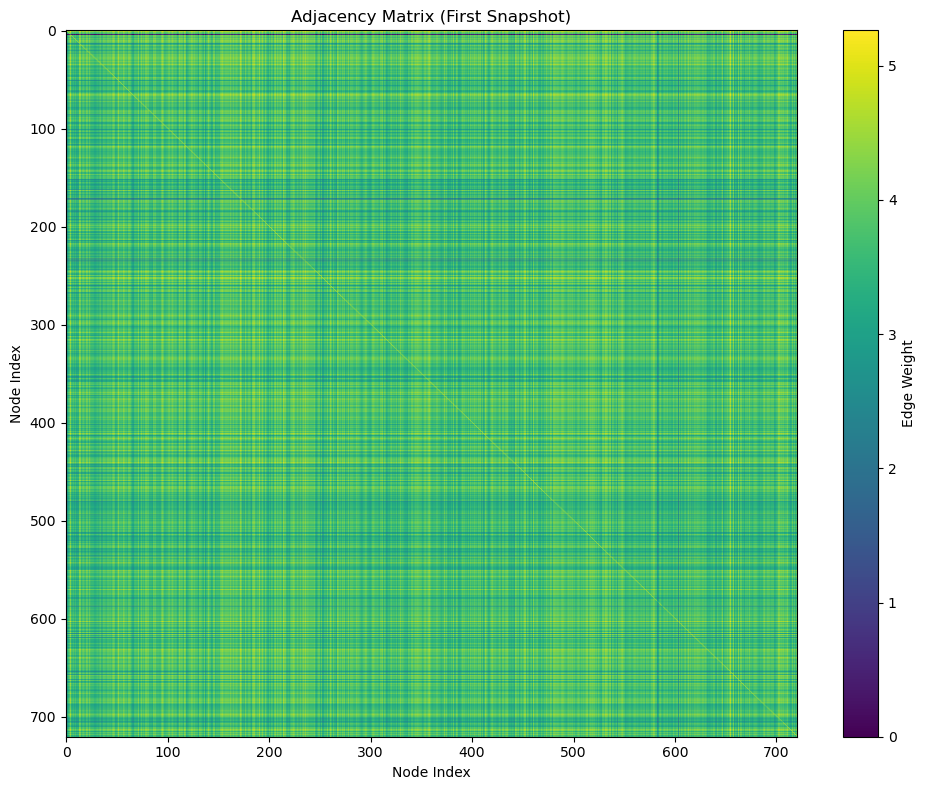

In [5]:
# Display the adjacency matrix with colorbar and legend
plt.figure(figsize=(10, 8))
im = plt.imshow(adj_matrices[0], cmap='viridis', aspect='auto')
plt.title('Adjacency Matrix (First Snapshot)')
plt.xlabel('Node Index')
plt.ylabel('Node Index')
plt.colorbar(im, label='Edge Weight')
plt.tight_layout()
plt.show()

Text(0.5, 0, 'Node Index of Most Correlated Stock')

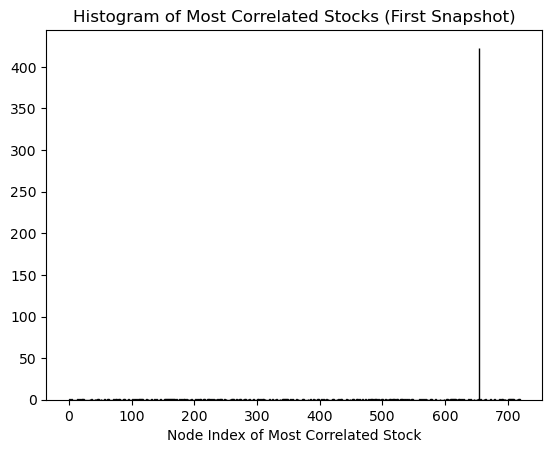

In [6]:
analyzer = train_analyzer
argmaxes_name = [ analyzer.index_to_stock[(adj_matrices[0][i].argmax().item())] for i in range(adj_matrices[0].shape[0]) ]
argmaxes = [ adj_matrices[0][i].argmax().item() for i in range(adj_matrices[0].shape[0]) ]
plt.hist(argmaxes, bins=analyzer.num_nodes, edgecolor='black')
plt.title('Histogram of Most Correlated Stocks (First Snapshot)')
plt.xlabel('Node Index of Most Correlated Stock')

In [7]:
np.unique(argmaxes_name, return_counts=True)


(array(['AAON', 'ABCO', 'ADRD', 'ADRE', 'ADTN', 'ADUS', 'AGYS', 'AIA',
        'ALCO', 'AMSF', 'ANDE', 'APEI', 'ARCB', 'ARLP', 'AROW', 'ARTNA',
        'ATLO', 'AVNW', 'BANF', 'BELFB', 'BFIN', 'BGFV', 'BMRC', 'BOOM',
        'BRKL', 'BSET', 'BSRR', 'BUSE', 'CAC', 'CARZ', 'CASH', 'CASS',
        'CCBG', 'CCNE', 'CFFI', 'CGO', 'CHCO', 'CHEF', 'CHI', 'CHSCP',
        'CHW', 'CHY', 'CIGI', 'CIVB', 'CMCO', 'CNOB', 'CNXN', 'COHU',
        'CRAI', 'CRESY', 'CRVL', 'CSPI', 'CTBI', 'CTRN', 'CVV', 'CWCO',
        'CZNC', 'DCOM', 'DGICA', 'DGII', 'DGLD', 'DHIL', 'DLBS', 'DMLP',
        'DMRC', 'DSGX', 'DSLV', 'DWAQ', 'DWPP', 'EBTC', 'EEMA', 'EFSC',
        'EMCB', 'EMIF', 'EML', 'ENZL', 'ESCA', 'ESSA', 'EWZS', 'FARM',
        'FBNC', 'FCBC', 'FDUS', 'FFBC', 'FFIC', 'FFNW', 'FIBK', 'FISI',
        'FLIC', 'FLXS', 'FMNB', 'FNLC', 'FORR', 'FRME', 'FRPH', 'FSTR',
        'FTCS', 'FTRI', 'FUNC', 'GABC', 'GAIN', 'GBDC', 'GDEN', 'GEOS',
        'GIFI', 'GLRE', 'GNMA', 'GOOD', 'GSBC', 'GULF', 'HAFC', 'HA

In [8]:
np.unique(argmaxes, return_counts=True)

(array([  0,   4,  13,  14,  16,  17,  20,  21,  23,  33,  36,  41,  43,
         45,  46,  47,  51,  56,  57,  61,  62,  63,  71,  74,  76,  78,
         79,  80,  81,  86,  87,  88,  94,  95, 101, 104, 105, 107, 108,
        111, 112, 113, 114, 116, 117, 123, 124, 126, 131, 132, 136, 140,
        145, 146, 152, 153, 154, 156, 157, 158, 159, 160, 162, 164, 165,
        167, 168, 171, 172, 176, 179, 180, 183, 184, 185, 188, 190, 193,
        196, 202, 205, 206, 208, 210, 211, 214, 215, 216, 221, 222, 223,
        224, 225, 227, 228, 230, 231, 233, 235, 237, 238, 240, 241, 242,
        244, 248, 249, 251, 257, 260, 261, 263, 267, 268, 270, 272, 273,
        274, 278, 280, 281, 282, 286, 288, 294, 295, 301, 302, 303, 306,
        309, 310, 311, 313, 320, 325, 329, 331, 337, 340, 341, 343, 344,
        345, 346, 347, 348, 349, 353, 354, 356, 357, 358, 362, 365, 372,
        374, 381, 384, 385, 390, 392, 396, 398, 402, 406, 408, 410, 413,
        419, 420, 422, 427, 430, 432, 433, 434, 442

In [9]:
# Analyze distribution of adjacency matrix values (edge weights)
if not skip_adj_distribution_analysis:
    edge_weights = []
    for adj in adj_matrices:
        # Get only the non-zero values (actual edges)
        non_zero_weights = adj[adj > 0]
        if len(non_zero_weights) > 0:
            edge_weights.extend(non_zero_weights)

    plt.figure(figsize=(10, 6))
    sns.histplot(edge_weights, bins=100, kde=True)
    plt.title('Edge Weight Distribution in Adjacency Matrices (Train)')
    plt.xlabel('Edge Weight')
    plt.ylabel('Frequency')
    plt.axvline(np.mean(edge_weights), color='red', linestyle='--', label=f'Mean: {np.mean(edge_weights):.4f}')
    plt.axvline(np.median(edge_weights), color='green', linestyle=':', label=f'Median: {np.median(edge_weights):.4f}')
    plt.legend()
    plt.show()

    # Summary statistics of edge weights
    edge_stats = pd.Series(edge_weights).describe()
    print("Edge Weight Statistics:")
    print(edge_stats)

## Node Features Analysis
Explore the distribution and statistics of node features across snapshots.

In [10]:
train_analyzer.analyze_node_features().groupby('ticker').describe()

Close                                                              \
        count      mean       std       min       25%       50%       75%   
ticker                                                                      
AAON    208.0  3.034004  0.110225  2.880925  2.920548  3.073308  3.140846   
AAPL    208.0  3.349062  0.148414  3.127038  3.249906  3.309717  3.504765   
AAXJ    208.0  3.943935  0.065621  3.816289  3.898276  3.943387  3.988254   
ABCB    208.0  3.586259  0.160558  3.311412  3.449094  3.691482  3.731295   
ABCO    208.0  0.814519  0.021576  0.762513  0.802180  0.816174  0.835407   
...       ...       ...       ...       ...       ...       ...       ...   
ZBRA    208.0  4.322368  0.214020  3.932020  4.204021  4.363050  4.497781   
ZEUS    208.0  3.084442  0.127700  2.857012  2.983254  3.099633  3.189146   
ZION    208.0  3.350479  0.191415  3.032630  3.177068  3.462892  3.526383   
ZIV     208.0  3.908100  0.166360  3.689249  3.771926  3.856268  4.048146   
ZUMZ    208.0  2.952519  0.158766  2.633578  2.846663  2.910312  3.057242   

                   High            ... node_idx        snapshot_idx         \
             max  count      mean  ...      75%    max        count   mean   
ticker                             ...                                       
AAON    3.191179  208.0  3.043844  ...      0.0    0.0        208.0  103.5   
AAPL    3.602525  208.0  3.354688  ...      1.0    1.0        208.0  103.5   
AAXJ    4.081709  208.0  3.947036  ...      2.0    2.0        208.0  103.5   
ABCB    3.774712  208.0  3.595945  ...      3.0    3.0        208.0  103.5   
ABCO    0.843990  208.0  0.815186  ...      4.0    4.0        208.0  103.5   
...          ...    ...       ...  ...      ...    ...          ...    ...   
ZBRA    4.666075  208.0  4.333671  ...    716.0  716.0        208.0  103.5   
ZEUS    3.301848  208.0  3.111955  ...    717.0  717.0        208.0  103.5   
ZION    3.587672  208.0  3.361205  ...    718.0  718.0        208.0  103.5   
ZIV     4.224857  208.0  3.914878  ...    719.0  719.0        208.0  103.5   
ZUMZ    3.251446  208.0  2.972673  ...    720.0  720.0        208.0  103.5   

                                                     
              std  min    25%    50%     75%    max  
ticker                                               
AAON    60.188592  0.0  51.75  103.5  155.25  207.0  
AAPL    60.188592  0.0  51.75  103.5  155.25  207.0  
AAXJ    60.188592  0.0  51.75  103.5  155.25  207.0  
ABCB    60.188592  0.0  51.75  103.5  155.25  207.0  
ABCO    60.188592  0.0  51.75  103.5  155.25  207.0  
...           ...  ...    ...    ...     ...    ...  
ZBRA    60.188592  0.0  51.75  103.5  155.25  207.0  
ZEUS    60.188592  0.0  51.75  103.5  155.25  207.0  
ZION    60.188592  0.0  51.75  103.5  155.25  207.0  
ZIV     60.188592  0.0  51.75  103.5  155.25  207.0  
ZUMZ    60.188592  0.0  51.75  103.5  155.25  207.0  

[721 rows x 56 columns]

 NODE FEATURE ANALYSIS


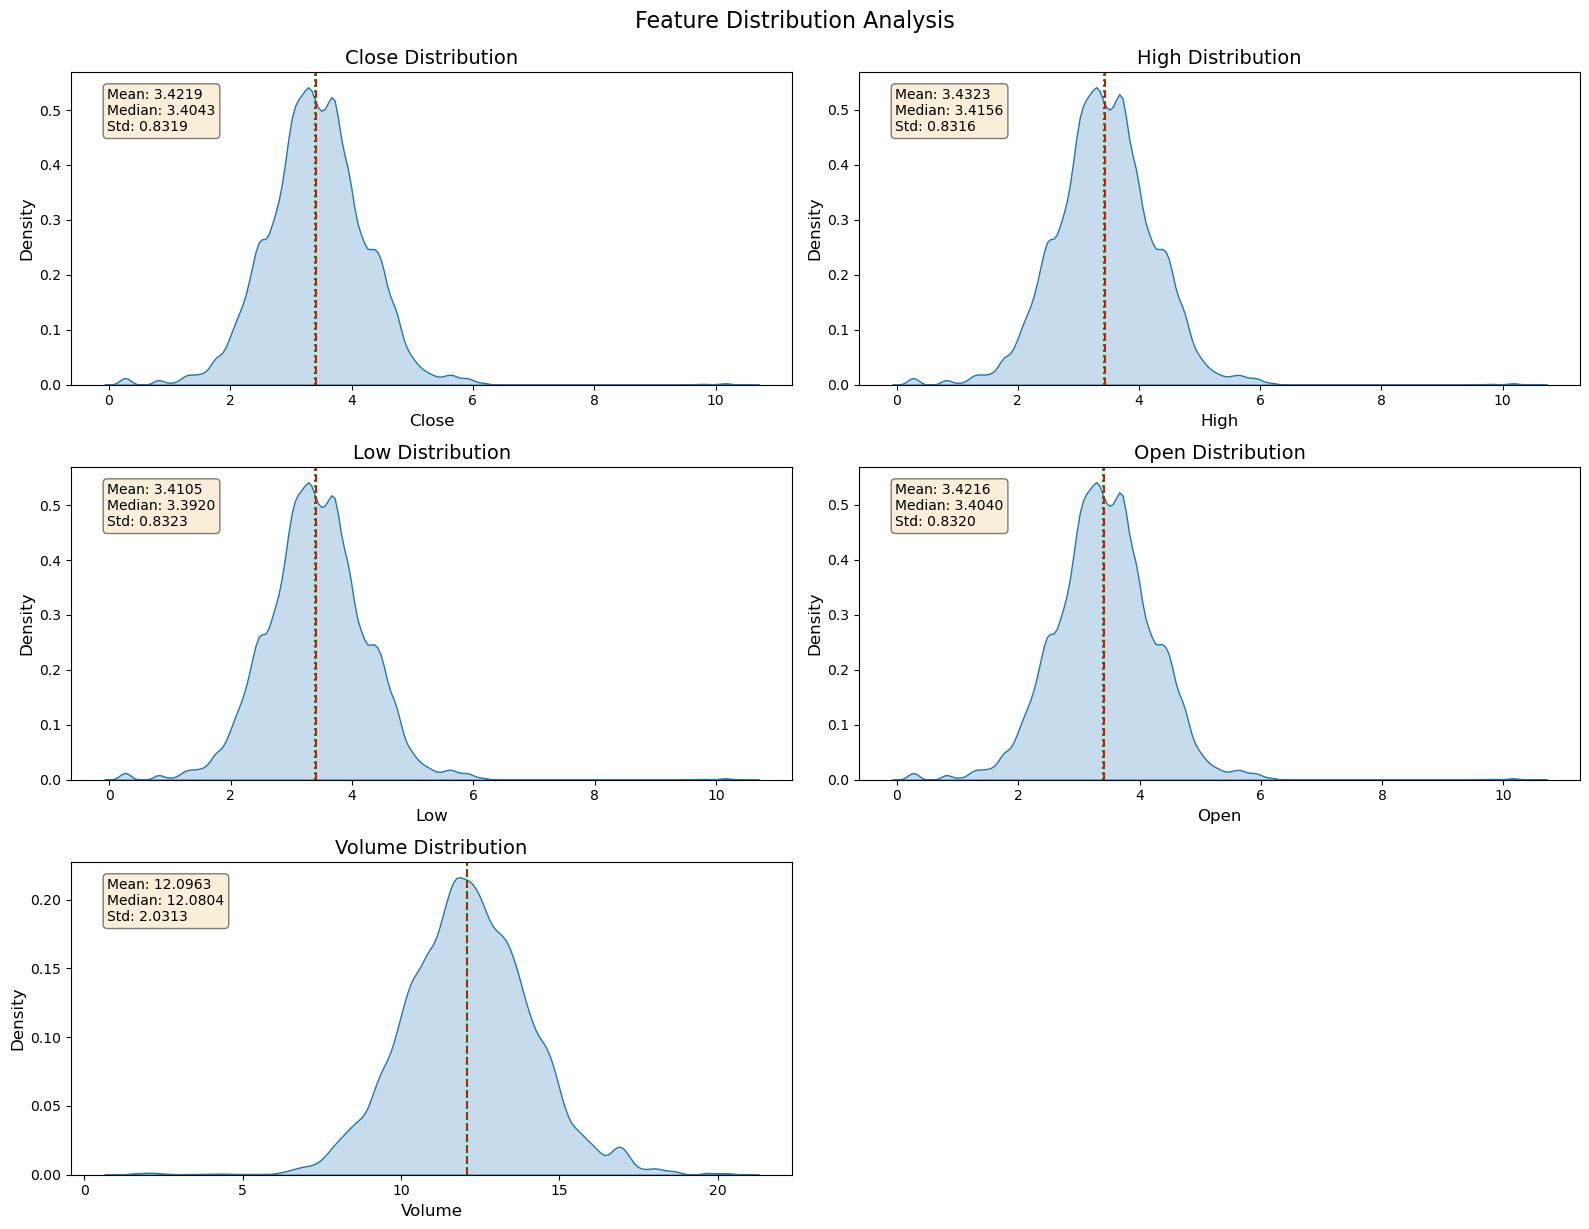

In [11]:
print("=" * 80)
print(" NODE FEATURE ANALYSIS")
print("=" * 80)

# Get the feature data
train_features_df = train_analyzer.analyze_node_features()

# 1. Feature Distribution Analysis with Advanced Visualization
plt.figure(figsize=(16, 12))
for i, feature in enumerate(train_analyzer.features, 1):
    plt.subplot(3, 2, i)
    # Use kernel density estimation for smoother visualization
    sns.kdeplot(data=train_features_df, x=feature, fill=True)
    plt.title(f'{feature} Distribution', fontsize=14)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel('Density', fontsize=12)
    
    # Add statistics to the plot
    mean_val = train_features_df[feature].mean()
    median_val = train_features_df[feature].median()
    std_val = train_features_df[feature].std()
    
    plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.4f}')
    plt.axvline(median_val, color='green', linestyle=':', label=f'Median: {median_val:.4f}')
    
    # Add text box with statistics
    stats_text = f"Mean: {mean_val:.4f}\nMedian: {median_val:.4f}\nStd: {std_val:.4f}"
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=10,
            verticalalignment='top', bbox=props)

plt.tight_layout()
plt.suptitle('Feature Distribution Analysis', fontsize=16, y=1.02)
plt.show()


== Derived Features Statistics ==


,volatility,daily_return,volume_price_ratio
count,149968.000000,149968.000000,149968.000000
mean,0.021796,0.000106,3.845977
std,0.010370,0.001216,2.300869
min,0.000146,-0.018885,0.267990
25%,0.014788,-0.000448,3.039303
50%,0.021320,0.000084,3.504879
75%,0.027875,0.000643,4.186588
max,0.104569,0.032213,61.921677


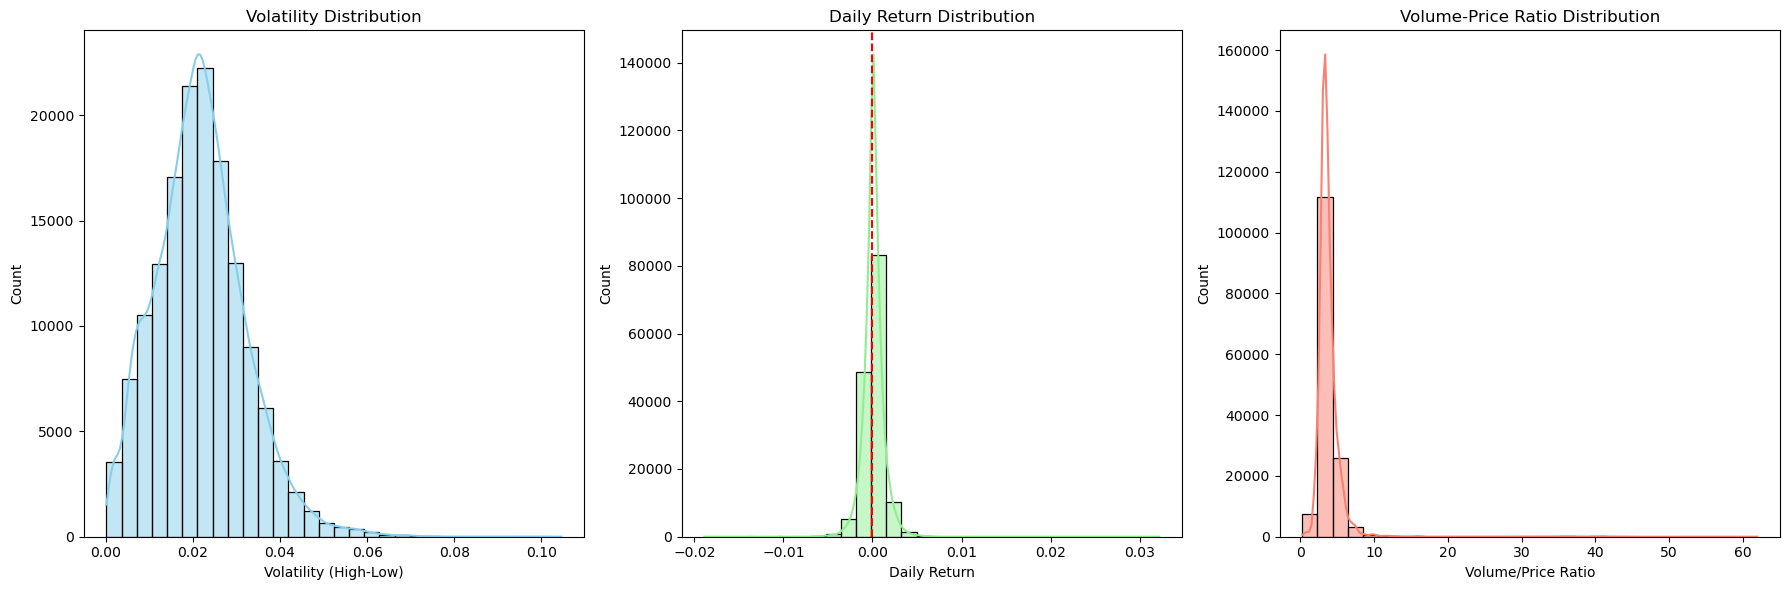

In [12]:
# 2. Calculate and analyze derived features
derived_features_df = train_analyzer.calculate_derived_features(train_features_df)

# Display summary of derived features
print("\n== Derived Features Statistics ==")
derived_stats = derived_features_df[['volatility', 'daily_return', 'volume_price_ratio']].describe()
display(derived_stats)

# Visualize derived features
plt.figure(figsize=(18, 6))

# Volatility distribution
plt.subplot(1, 3, 1)
sns.histplot(derived_features_df['volatility'], kde=True, bins=30, color='skyblue')
plt.title('Volatility Distribution')
plt.xlabel('Volatility (High-Low)')

# Daily return distribution
plt.subplot(1, 3, 2)
sns.histplot(derived_features_df['daily_return'], kde=True, bins=30, color='lightgreen')
plt.title('Daily Return Distribution')
plt.xlabel('Daily Return')
plt.axvline(0, color='red', linestyle='--')

# Volume-price ratio
plt.subplot(1, 3, 3)
sns.histplot(derived_features_df['volume_price_ratio'], kde=True, bins=30, color='salmon')
plt.title('Volume-Price Ratio Distribution')
plt.xlabel('Volume/Price Ratio')

plt.tight_layout()
plt.show()

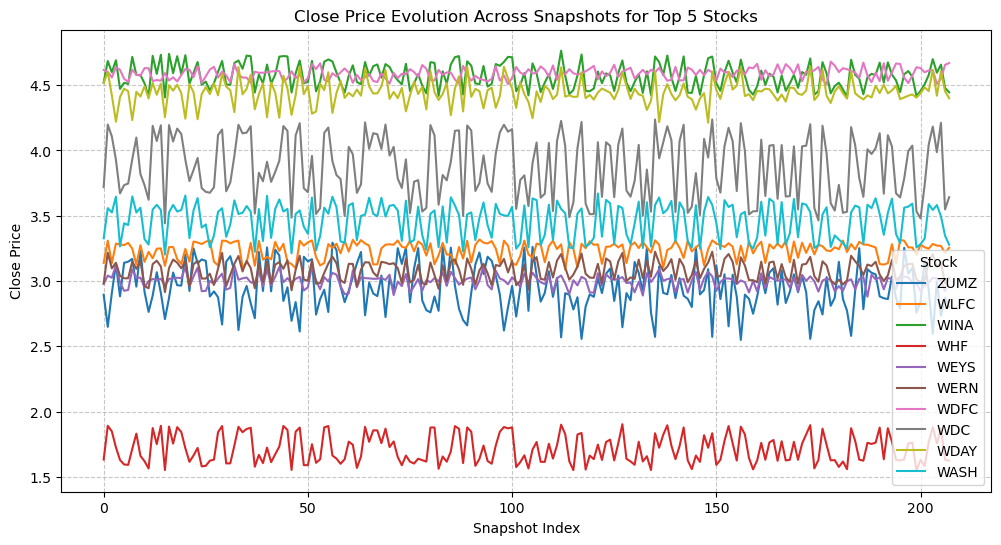

In [13]:
# 3. Time Series Analysis of Features
# Get Close price time series for top 5 stocks by market cap (for example)
top_stocks = train_features_df['ticker'].value_counts().head(10).index.tolist()
close_ts_data = pd.DataFrame()

for stock in top_stocks:
    ts_data = train_analyzer.get_feature_timeseries(stock_ticker=stock, feature='Close')
    close_ts_data = pd.concat([close_ts_data, ts_data])

# Plot time series
plt.figure(figsize=(12, 6))
sns.lineplot(data=close_ts_data, x='snapshot', y='value', hue='ticker')
plt.title('Close Price Evolution Across Snapshots for Top 5 Stocks')
plt.xlabel('Snapshot Index')
plt.ylabel('Close Price')
plt.legend(title='Stock')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

<Figure size 1200x1000 with 0 Axes>

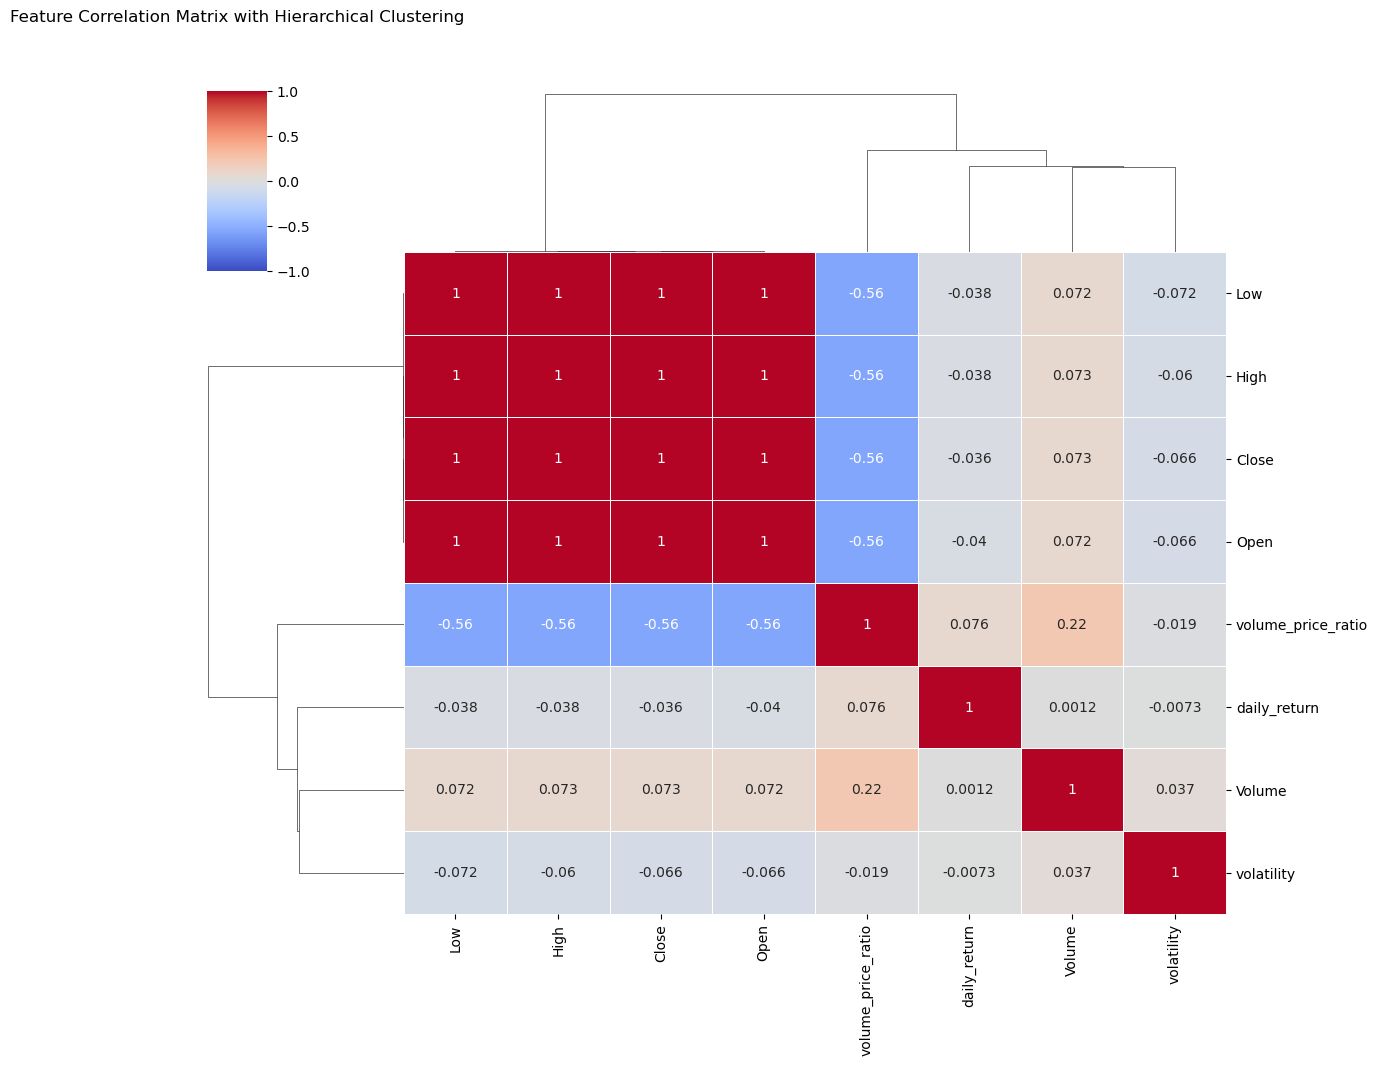

In [14]:
# 4. Feature Correlation Heatmap with Clustering
plt.figure(figsize=(12, 10))
# Include derived features in correlation analysis
corr_columns = train_analyzer.features + ['volatility', 'daily_return', 'volume_price_ratio']
corr_matrix = derived_features_df[corr_columns].corr()

# Use hierarchical clustering to group correlated features
g = sns.clustermap(
    corr_matrix, 
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    figsize=(12, 10)
)
plt.title('Feature Correlation Matrix with Hierarchical Clustering', pad=50)
plt.show()

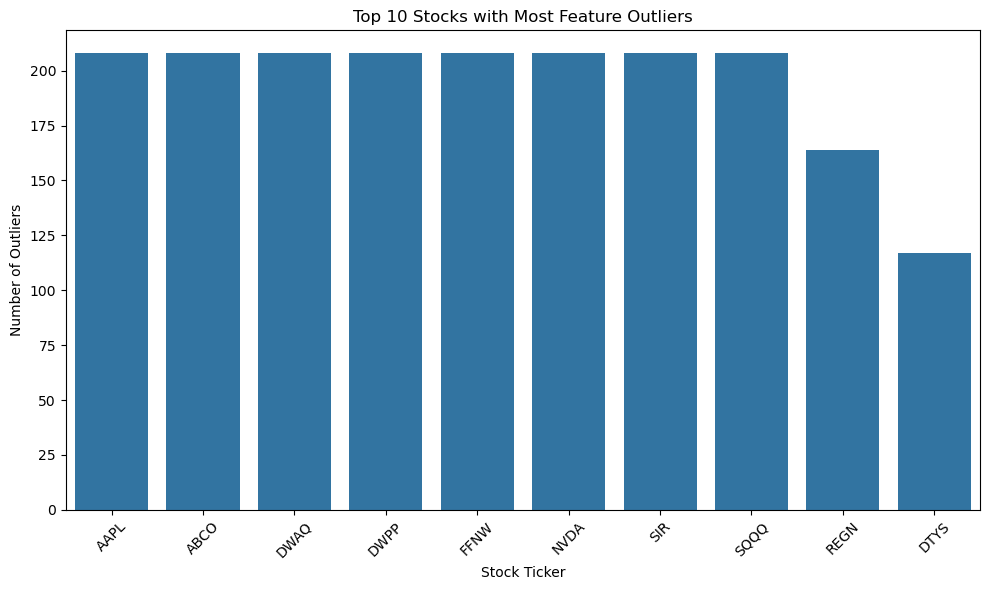

In [15]:
# 5. Outlier Analysis
# Calculate Z-scores for each feature
z_scores = {}
for feature in train_analyzer.features:
    z_scores[feature] = (train_features_df[feature] - train_features_df[feature].mean()) / train_features_df[feature].std()

# Identify potential outliers (|z-score| > 3)
outliers_df = pd.DataFrame(z_scores)
outliers_df['ticker'] = train_features_df['ticker']
outliers_df['snapshot_idx'] = train_features_df['snapshot_idx']
outliers_df['is_outlier'] = (abs(outliers_df[train_analyzer.features]) > 3).any(axis=1)

# Count outliers by ticker
outlier_counts = outliers_df[outliers_df['is_outlier']].ticker.value_counts()
top_outlier_tickers = outlier_counts.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_outlier_tickers.index, y=top_outlier_tickers.values)
plt.title('Top 10 Stocks with Most Feature Outliers')
plt.xlabel('Stock Ticker')
plt.ylabel('Number of Outliers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

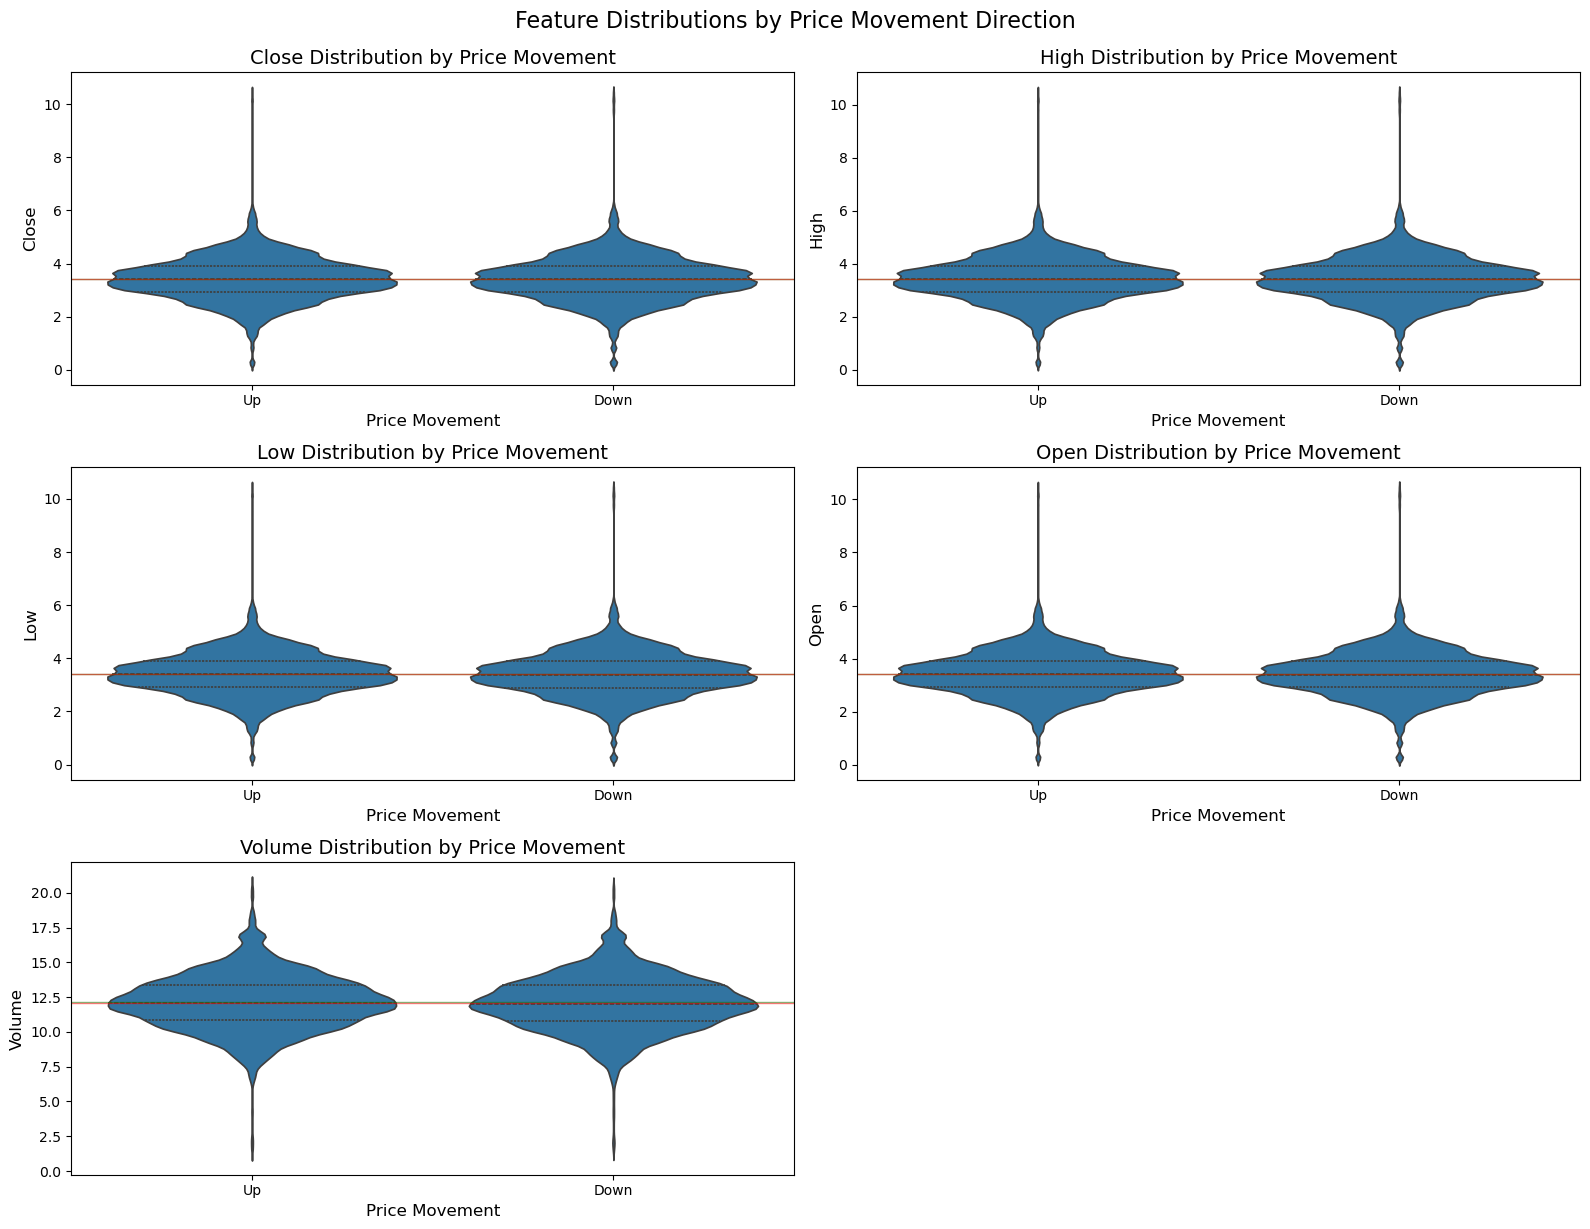

In [16]:
# 6. Node Feature Analysis by Target (Up/Down) - More Advanced
feature_target_df = train_features_df.copy()
# Add target information
feature_target_df['target'] = np.nan  # Initialize with NaN

# Populate target values from each snapshot
for i in range(train_analyzer.num_snapshots):
    snapshot = train_analyzer.graph_snapshots[i]
    targets = snapshot.y.numpy()
    mask = (feature_target_df['snapshot_idx'] == i)
    feature_target_df.loc[mask, 'target'] = np.tile(targets, mask.sum() // len(targets))

feature_target_df['target_category'] = np.where(feature_target_df['target'] > 0, 'Up', 'Down')

# Create violin plots to show distribution differences
plt.figure(figsize=(16, 12))
for i, feature in enumerate(train_analyzer.features, 1):
    plt.subplot(3, 2, i)
    sns.violinplot(x='target_category', y=feature, data=feature_target_df, inner='quartile')
    plt.title(f'{feature} Distribution by Price Movement', fontsize=14)
    plt.xlabel('Price Movement', fontsize=12)
    plt.ylabel(feature, fontsize=12)
    
    # Add mean lines
    means = feature_target_df.groupby('target_category')[feature].mean()
    plt.axhline(y=means['Up'], color='green', linestyle='-', linewidth=1, alpha=0.5)
    plt.axhline(y=means['Down'], color='red', linestyle='-', linewidth=1, alpha=0.5)
    
plt.tight_layout()
plt.suptitle('Feature Distributions by Price Movement Direction', fontsize=16, y=1.02)
plt.show()

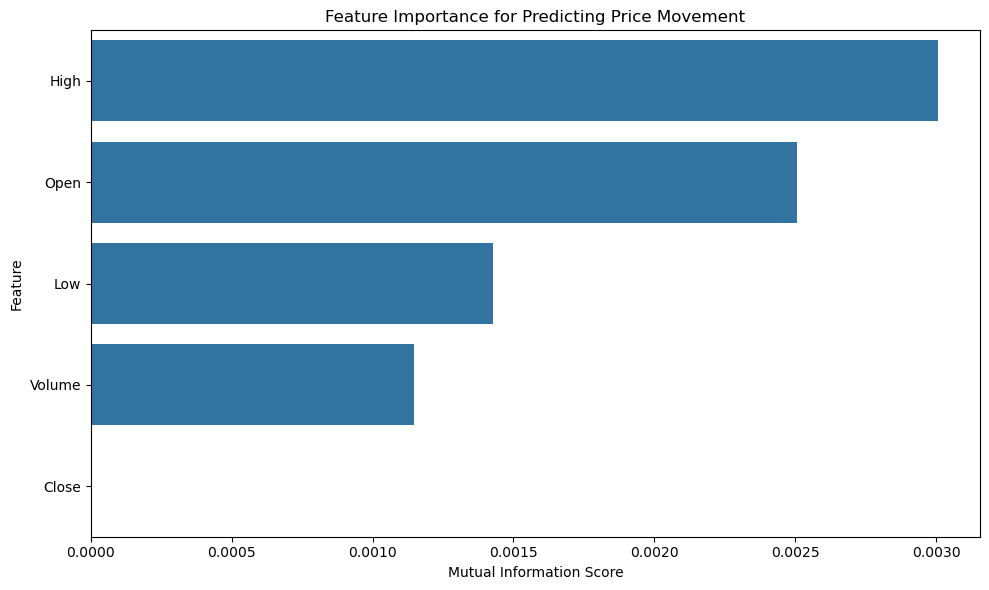

In [17]:
# 7. Feature Importance for Predicting Price Movement
from sklearn.feature_selection import mutual_info_classif

# Calculate mutual information between features and target
X = feature_target_df[train_analyzer.features] #+ ['volatility', 'daily_return', 'volume_price_ratio']]
y = (feature_target_df['target'] > 0).astype(int)  # 1 for Up, 0 for Down

# Handle NaN values
X = X.fillna(X.mean())
valid_mask = ~y.isna()
X_valid = X[valid_mask]
y_valid = y[valid_mask]

mi_scores = mutual_info_classif(X_valid, y_valid)
mi_results = pd.Series(mi_scores, index=X.columns)
mi_results = mi_results.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=mi_results.values, y=mi_results.index)
plt.title('Feature Importance for Predicting Price Movement')
plt.xlabel('Mutual Information Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Adjacency Matrix Comparison
Compare adjacency matrices across different snapshots to observe temporal changes in the graph structure.

/tmp/ipykernel_1969509/4010749146.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


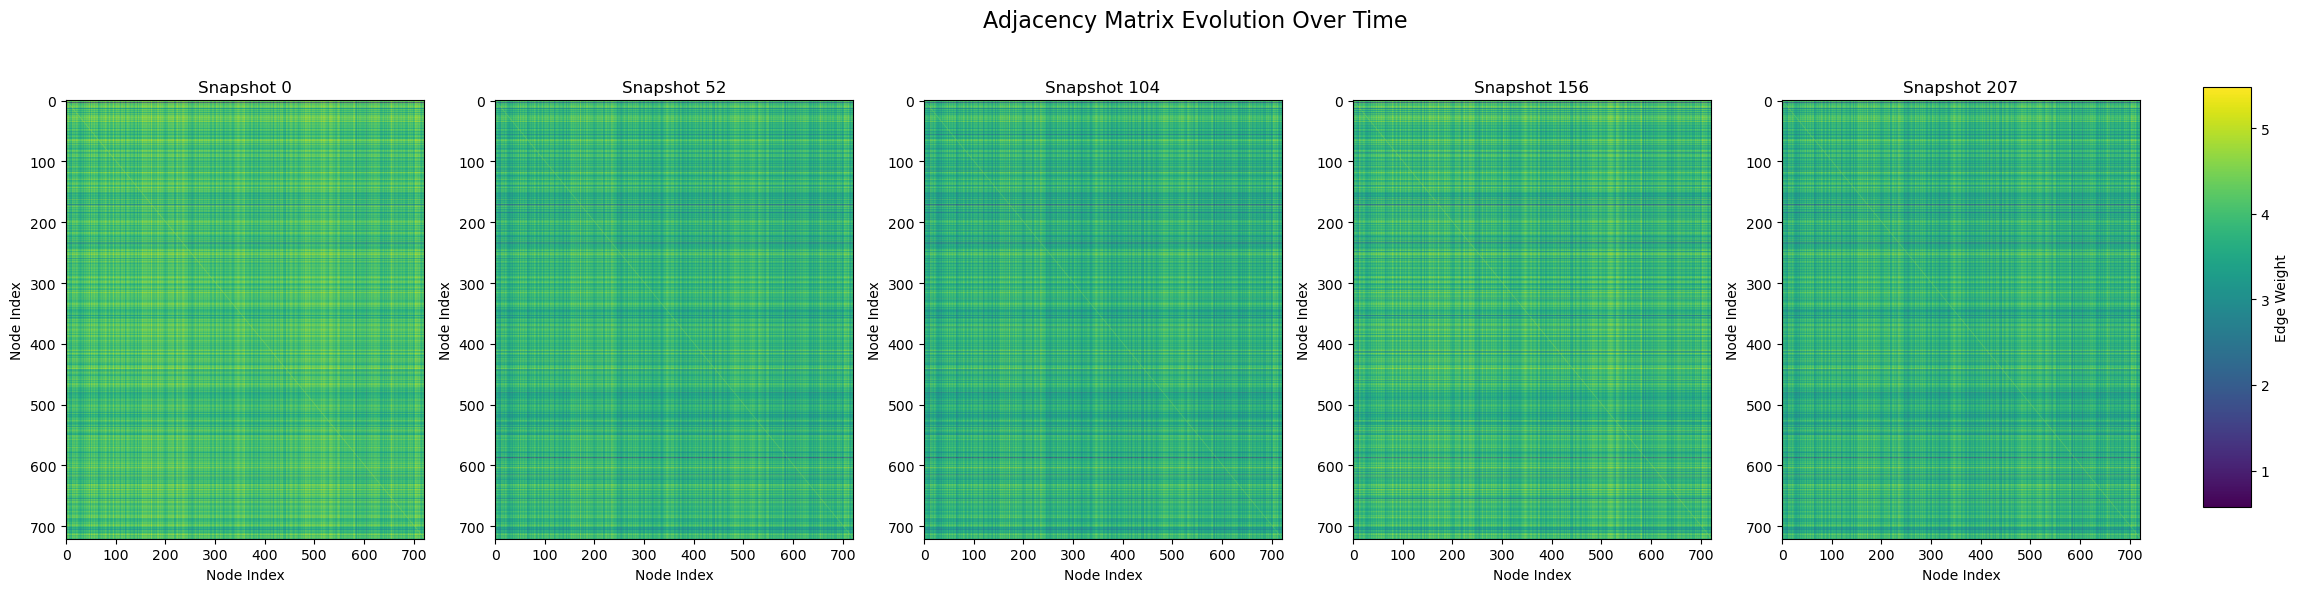

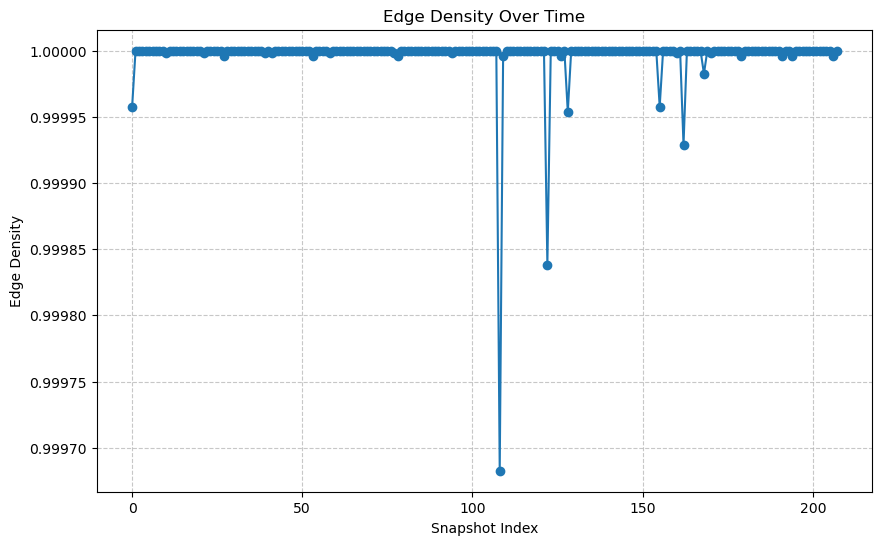

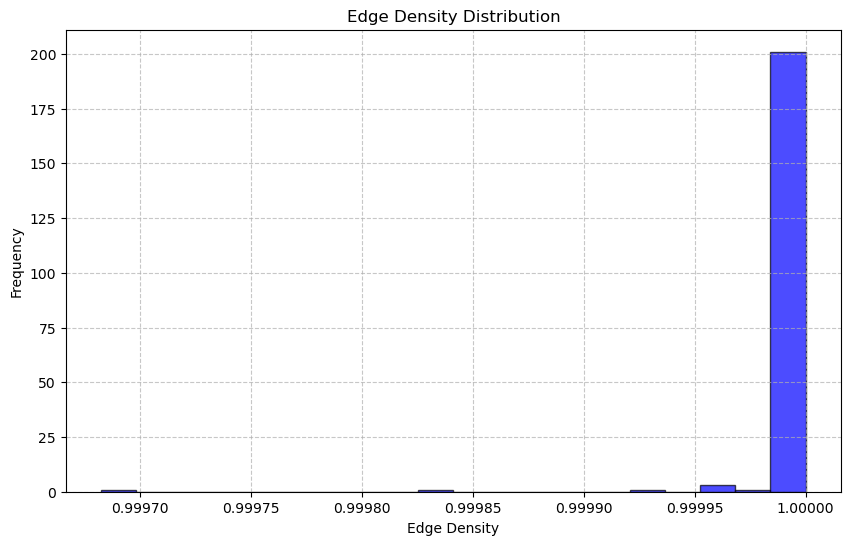

In [18]:
# Compare adjacency matrices at different time points
snapshot_indices = [0, len(adj_matrices)//4, len(adj_matrices)//2, 3*len(adj_matrices)//4, len(adj_matrices)-1]  # First, middles, last
fig, axes = plt.subplots(1, 5, figsize=(24, 6))

for i, idx in enumerate(snapshot_indices):
    im = axes[i].imshow(adj_matrices[idx], cmap='viridis', aspect='auto')
    axes[i].set_title(f'Snapshot {idx}')
    axes[i].set_xlabel('Node Index')
    axes[i].set_ylabel('Node Index')

# Add colorbar to the right of the last image
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Edge Weight')

plt.suptitle('Adjacency Matrix Evolution Over Time', fontsize=16)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()

# Analyze how edge density changes over time
edge_density = [np.count_nonzero(adj)/adj.size for adj in adj_matrices]
plt.figure(figsize=(10, 6))
plt.plot(edge_density, 'o-')
plt.title('Edge Density Over Time')
plt.xlabel('Snapshot Index')
plt.ylabel('Edge Density')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


plt.figure(figsize=(10, 6))
plt.hist(edge_density, bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title('Edge Density Distribution')
plt.xlabel('Edge Density')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Homophily Analysis
Calculate and visualize homophily for each snapshot (fraction of edges connecting nodes with the same label).

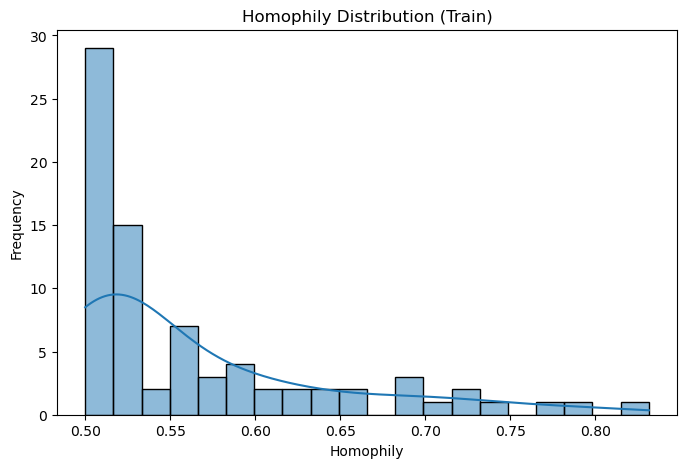

In [19]:
homophily_scores = []

analyzer = val_analyzer

for sample_idx in range(len(analyzer.graph_snapshots)):
    homophily_score = analyzer.get_homophily_score(sample_idx)
    homophily_scores.append(homophily_score)


plt.figure(figsize=(8, 5))
sns.histplot(homophily_scores, bins=20, kde=True)
plt.title('Homophily Distribution (Train)')
plt.xlabel('Homophily')
plt.ylabel('Frequency')
plt.show()

## Up Ratios Analysis
Visualize the distribution of up ratios (fraction of nodes with positive label) for each dataset.

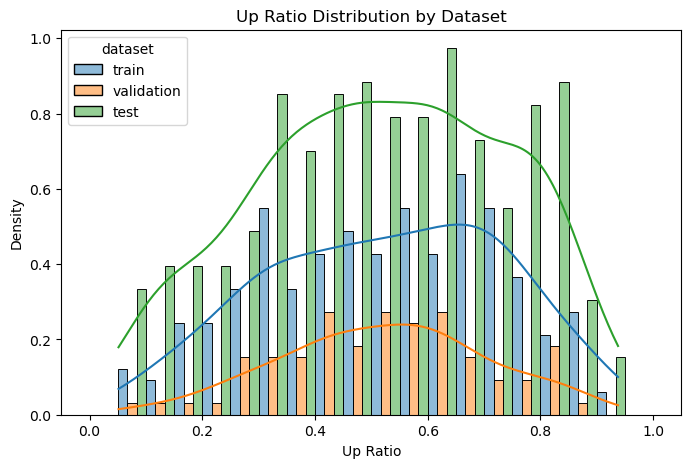

In [20]:
plt.figure(figsize=(8, 5))
sns.histplot(data=all_snapshots_df, x='up_ratio', hue='dataset', multiple='dodge', kde=True, binrange=(0, 1), binwidth=.05, stat='density')
plt.title('Up Ratio Distribution by Dataset')
plt.xlabel('Up Ratio')
plt.ylabel('Density')
plt.show()

## Connectivity Analysis
Compare connectivity statistics across datasets.

In [21]:
all_snapshots_df.groupby('dataset')['connectivity'].describe()

,count,mean,std,min,25%,50%,75%,max
dataset,,,,,,,,
test,371.0,1.001382,0.000036,1.000986,1.001389,1.001389,1.001389,1.001389
train,208.0,1.001385,0.000026,1.001071,1.001389,1.001389,1.001389,1.001389
validation,78.0,1.001379,0.000028,1.001177,1.001383,1.001388,1.001389,1.001389


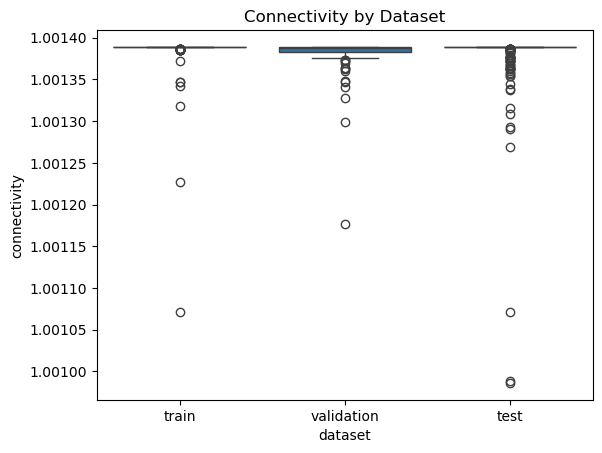

In [22]:
sns.boxplot(data=all_snapshots_df, x='dataset', y='connectivity')
plt.title('Connectivity by Dataset')
plt.show()

## Summary Statistics
Show summary statistics for key metrics in each dataset.

In [23]:
summary = all_snapshots_df.groupby('dataset')[['up_ratio', 'connectivity']].describe()
summary

up_ratio                                                    \
              count      mean       std       min       25%       50%   
dataset                                                                 
test          371.0  0.516275  0.220396  0.051318  0.349515  0.518724   
train         208.0  0.523538  0.209482  0.062413  0.353675  0.531207   
validation     78.0  0.522778  0.179472  0.092926  0.404646  0.532594   

                               connectivity                                \
                 75%       max        count      mean       std       min   
dataset                                                                     
test        0.690014  0.937587        371.0  1.001382  0.000036  1.000986   
train       0.691054  0.929265        208.0  1.001385  0.000026  1.001071   
validation  0.629334  0.877947         78.0  1.001379  0.000028  1.001177   

                                                    
                 25%       50%       75%       max  
dataset                                             
test        1.001389  1.001389  1.001389  1.001389  
train       1.001389  1.001389  1.001389  1.001389  
validation  1.001383  1.001388  1.001389  1.001389

In [ ]:
# Inter-Market Analysis of Train, Validation, and Test Sets
from dataset_analyzer import *
plt.rcParams['figure.figsize'] = (16, 12)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

# Create a function to compare dataset statistics
# Run the analysis
analyzers = [train_analyzer, val_analyzer, test_analyzer]
names = ['Train', 'Validation', 'Test']

print("1. Dataset Statistics Comparison")
display(compare_dataset_stats(analyzers, names))

print("\n2. Degree Distribution Analysis")
plot_degree_distributions(analyzers, names)

print("\n3. Snapshot Statistics Comparison")
compare_snapshot_stats(analyzers, names)

print("\n4. Feature Distributions Comparison")
compare_feature_distributions(analyzers, names)

print("\n5. Time Series Analysis")
compare_time_series(analyzers, names, feature='Close')

print("\n6. Network Structure Visualization")
compare_adjacency_heatmaps(analyzers, names)

print("\n7. Derived Features Analysis")
compare_derived_features(analyzers, names)

1. Dataset Statistics Comparison


,Dataset,Market,Time Period,Num Nodes,Num Snapshots,Window Size,Normalizer
0,Train,NASDAQ,2016-05-01-2017-06-30,721,208,19,log1p
1,Validation,NASDAQ,2017-07-01-2017-12-31,721,78,19,log1p
2,Test,NASDAQ,2018-01-01-2019-12-31,721,371,19,log1p



2. Degree Distribution Analysis
